In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, recall_score, roc_auc_score, cohen_kappa_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

### Load data

In [2]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [3]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [4]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


# Decision Tree

## Simple mode

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)


DecisionTreeClassifier(random_state=42)

In [6]:
y_pred = dt.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred, digits=3))


Classification Report:
               precision    recall  f1-score   support

           0      0.714     0.672     0.692       707
           1      0.626     0.672     0.648       579

    accuracy                          0.672      1286
   macro avg      0.670     0.672     0.670      1286
weighted avg      0.675     0.672     0.673      1286



### Average Precision Score

In [7]:
y_probas = dt.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.5694980017178906


## Hyperparameter Tuning

In [8]:
params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 12],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params,
    scoring='recall',        
    cv=10,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)


Fitting 10 folds for each of 64 candidates, totalling 640 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [2, 5, 10, 12]},
             scoring='recall', verbose=1)

In [9]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best cross-validation recall score: {grid_search.best_score_:.3f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 12}
Best cross-validation recall score: 0.765


In [10]:
dt_tune = grid_search.best_estimator_
y_pred_tune = dt_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_tune, digits=3))

Classification Report:
               precision    recall  f1-score   support

           0      0.766     0.593     0.668       707
           1      0.610     0.779     0.684       579

    accuracy                          0.677      1286
   macro avg      0.688     0.686     0.676      1286
weighted avg      0.696     0.677     0.676      1286



### Average precision

In [11]:
y_probas_tune = dt_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.6899851798047728


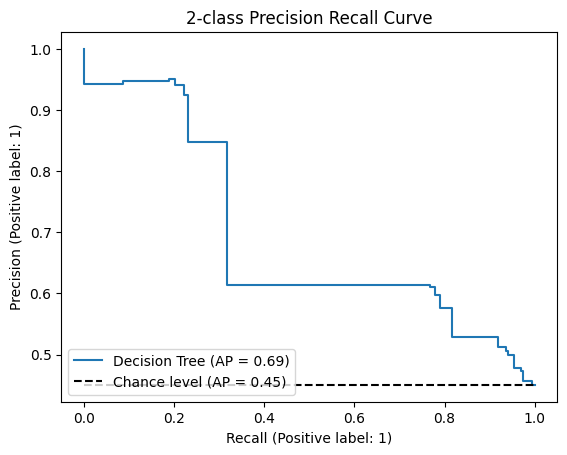

In [12]:
display = PrecisionRecallDisplay.from_estimator(
    dt_tune,
    X_test,
    y_test, 
    name="Decision Tree",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Recall score on train set

In [13]:
# Recall on base model
y_train_pred = dt.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Base Model): {train_recall:.3f}")

# Recall on tune tune model
y_train_pred = dt_tune.predict(X_train_sm)
train_recall = recall_score(y_train_sm, y_train_pred)
print(f"Recall on Training set (Tune Model): {train_recall:.3f}")

Recall on Training set (Base Model): 0.987
Recall on Training set (Tune Model): 0.768


### AUC score

In [14]:
auc = roc_auc_score(y_test, y_probas)
print(f"AUC: {auc:.3f}")

auc_tune = roc_auc_score(y_test, y_probas_tune)
print(f"AUC: {auc_tune:.3f}")

AUC: 0.673
AUC: 0.747


### Cohen's Kappa

In [15]:
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.3f}")

kappa_tune = cohen_kappa_score(y_test, y_pred_tune)
print(f"Cohen's Kappa: {kappa_tune:.3f}")

Cohen's Kappa: 0.341
Cohen's Kappa: 0.363


### Confusion matrix

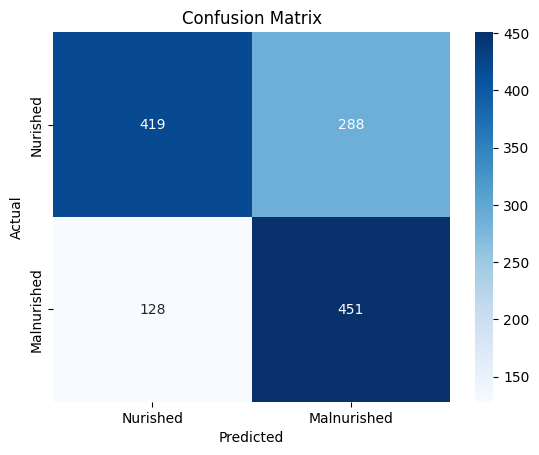

In [16]:
cm = confusion_matrix(y_test, y_pred_tune)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature importance

In [17]:
# Get feature importances in simple model
feature_importance = dt.feature_importances_
feature_names = X_train_sm.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                   Feature  Importance
1             child_weight    0.386849
0                child_age    0.139000
8             wealth_index    0.095341
6         mother_education    0.079671
3       fever_last_2_weeks    0.042966
4                     area    0.040153
5                child_sex    0.040028
11            province_3.0    0.027582
2   diarrhoea_last_2_weeks    0.024259
10            province_2.0    0.020257
13            province_5.0    0.020084
15            province_7.0    0.019880
14            province_6.0    0.018525
9             province_1.0    0.016974
12            province_4.0    0.016972
7         health_insurance    0.011458


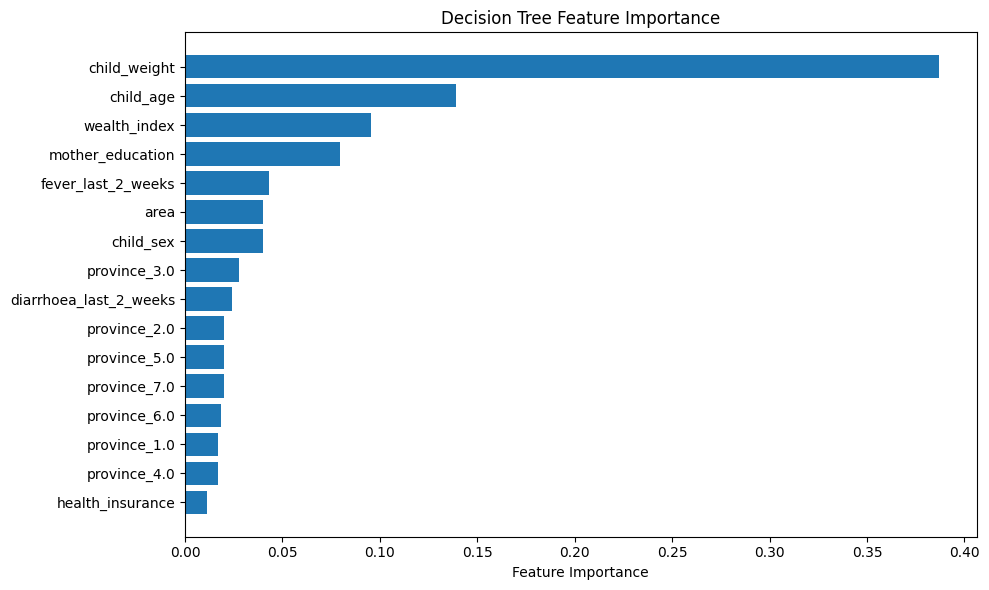

In [18]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# Get feature importances in tuned model
feature_importance = dt_tune.feature_importances_
feature_names = X_train_sm.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display
print(importance_df)

                   Feature  Importance
1             child_weight    0.623755
0                child_age    0.333536
6         mother_education    0.011734
4                     area    0.007379
9             province_1.0    0.006061
15            province_7.0    0.005373
7         health_insurance    0.004236
10            province_2.0    0.003205
8             wealth_index    0.002529
12            province_4.0    0.002191
2   diarrhoea_last_2_weeks    0.000000
3       fever_last_2_weeks    0.000000
5                child_sex    0.000000
11            province_3.0    0.000000
13            province_5.0    0.000000
14            province_6.0    0.000000


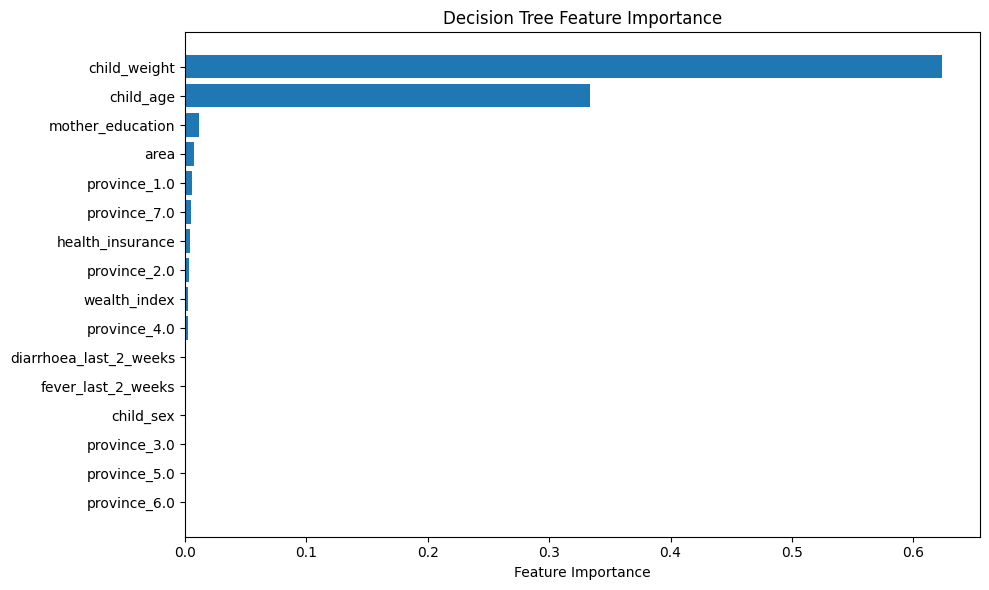

In [20]:
# Bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


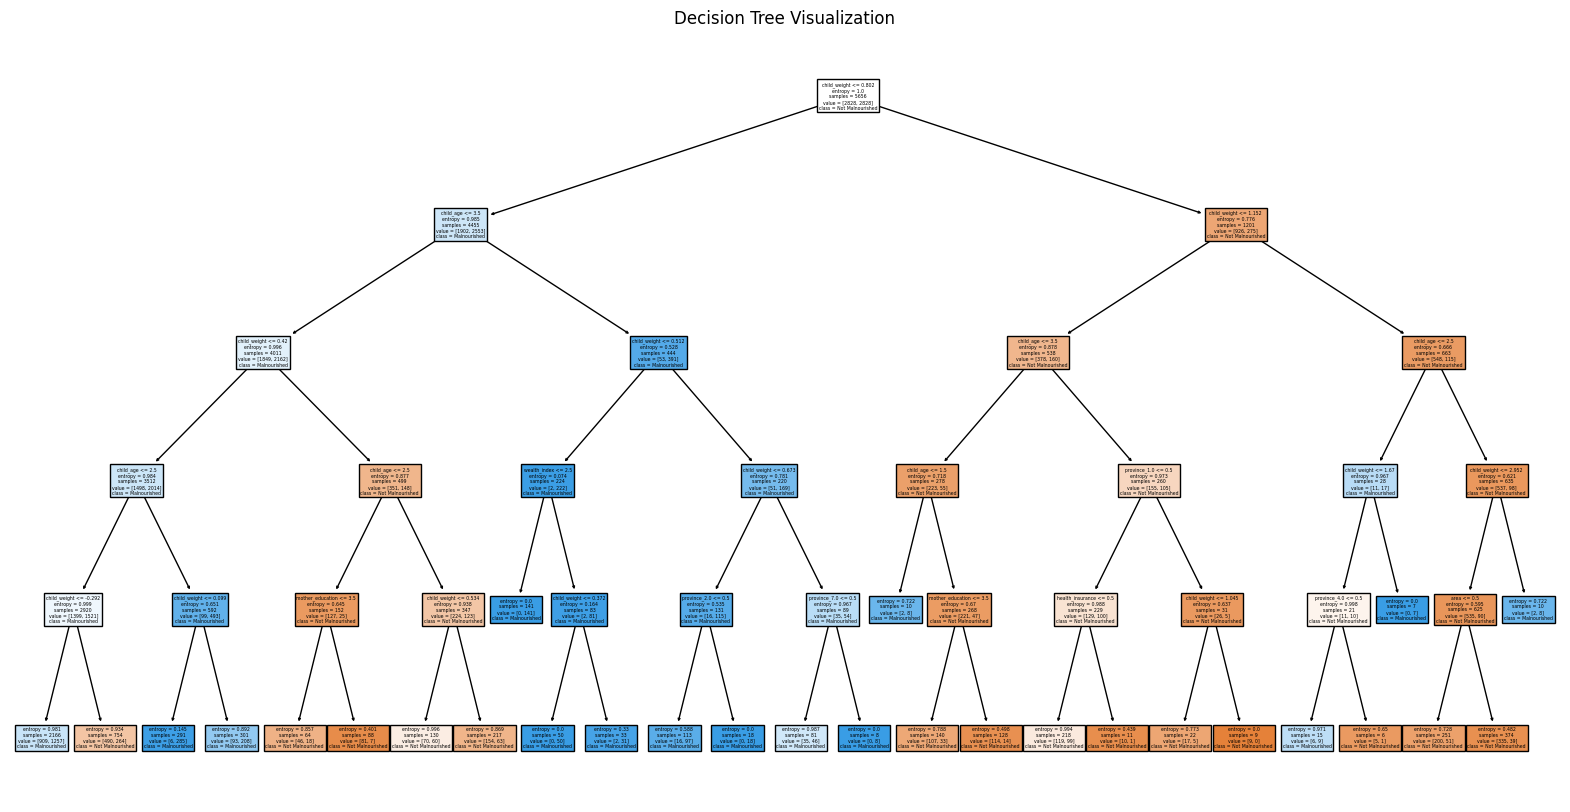

In [21]:
plt.figure(figsize=(20, 10))
plot_tree(dt_tune, feature_names=X.columns, class_names=['Not Malnourished', 'Malnourished'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

## Additional

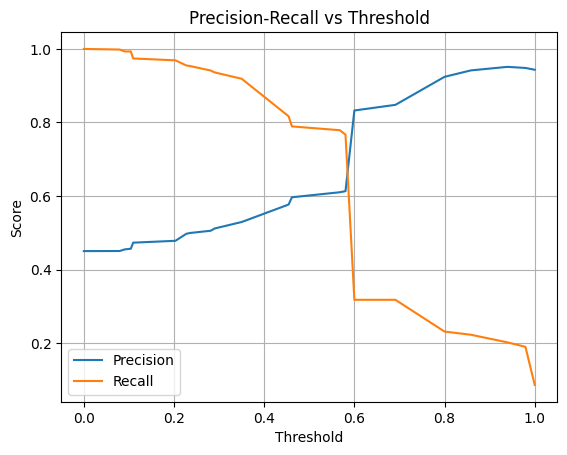

In [22]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probas_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [23]:
# Apply custom threshold
y_probas_custom = (y_probas_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.51      0.61       707
           1       0.58      0.82      0.68       579

    accuracy                           0.65      1286
   macro avg       0.67      0.66      0.65      1286
weighted avg       0.68      0.65      0.64      1286


